In [4]:
from sklearn.datasets import fetch_openml
import pandas as pd

# load leukemia dataset
leukemia = fetch_openml(name="leukemia", version=1, as_frame=True)

df = leukemia.frame

print("Dataset loaded!")
print(df.shape)
df.head()

Dataset loaded!
(72, 7130)


,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,CLASS
0,-214,-153,-58,88,-295,-558,199,-176,252,206,...,511,-125,389,-37,793,329,36,191,-37,ALL
1,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,837,-36,442,-17,782,295,11,76,-14,ALL
2,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,1199,33,168,52,1138,777,41,228,-41,ALL
3,-135,-114,265,12,-419,-585,158,-253,49,31,...,835,218,174,-110,627,170,-50,126,-91,ALL
4,-106,-125,-76,168,-230,-284,4,-122,70,252,...,649,57,504,-26,250,314,14,56,-25,ALL


In [5]:
# separate features and labels
X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

KeyError: "['target'] not found in axis"

In [1]:
print("Project setup complete")

Project setup complete


In [2]:
!pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn requests


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import xgboost as xgb

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


In [4]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current working directory:
C:\aml_multiomics_ai\notebooks

Files and folders here:
['.ipynb_checkpoints', '01_setup.ipynb']


In [5]:
data_path = "../data/raw"

print("Data folder path:", data_path)

Data folder path: ../data/raw


In [6]:
import os

print(os.listdir("../data"))

['interim', 'processed', 'raw']


In [8]:
from sklearn.datasets import fetch_openml
import pandas as pd

# download leukemia dataset
leukemia = fetch_openml(name="leukemia", version=1, as_frame=True)

# separate features and labels
X = leukemia.data
y = leukemia.target

print("Dataset loaded successfully!")
print("Samples:", X.shape[0])
print("Genes:", X.shape[1])

X.head()

Dataset loaded successfully!
Samples: 72
Genes: 7129


,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
1,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
2,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
3,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
4,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [9]:
# check the shape of the dataset
print("Feature matrix shape:", X.shape)

# see first few rows
X.head()

Feature matrix shape: (72, 7129)


,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
1,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
2,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
3,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
4,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [10]:
# check the target labels
print("Label distribution:")
print(y.value_counts())

Label distribution:
CLASS
ALL    47
AML    25
Name: count, dtype: int64


In [11]:
# convert labels into numbers
y_encoded = y.map({"ALL": 0, "AML": 1})

print("Encoded labels:")
print(y_encoded.value_counts())

Encoded labels:
CLASS
0    47
1    25
Name: count, dtype: int64


In [12]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 57
Testing samples: 15


In [14]:
# make predictions on the test set
y_pred = model.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model accuracy:", accuracy)

Model accuracy: 0.9333333333333333


In [15]:
# show detailed performance metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



In [16]:
from sklearn.metrics import confusion_matrix

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0]
 [ 1  4]]


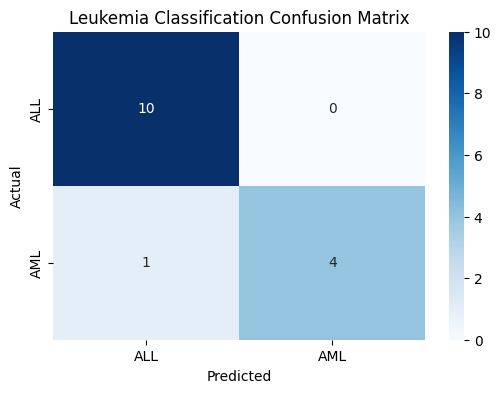

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ALL","AML"],
            yticklabels=["ALL","AML"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Leukemia Classification Confusion Matrix")

plt.show()

In [18]:
# get feature importance from the model
importances = model.feature_importances_

# create a dataframe for easier viewing
feature_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": importances
})

# sort by importance
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# show top 10 most important genes
feature_importance.head(10)

,Gene,Importance
6854,M31523_at,0.312637
1833,M23197_at,0.186899
1881,M27891_at,0.163405
2287,M84526_at,0.150370
3251,U46499_at,0.077437
6040,L09209_s_at,0.045184
4376,X62654_rna1_at,0.028337
38,AFFX-HUMRGE/M10098_5_at,0.013114
166,D00726_at,0.010905
3,AFFX-BioC-5_at,0.008099


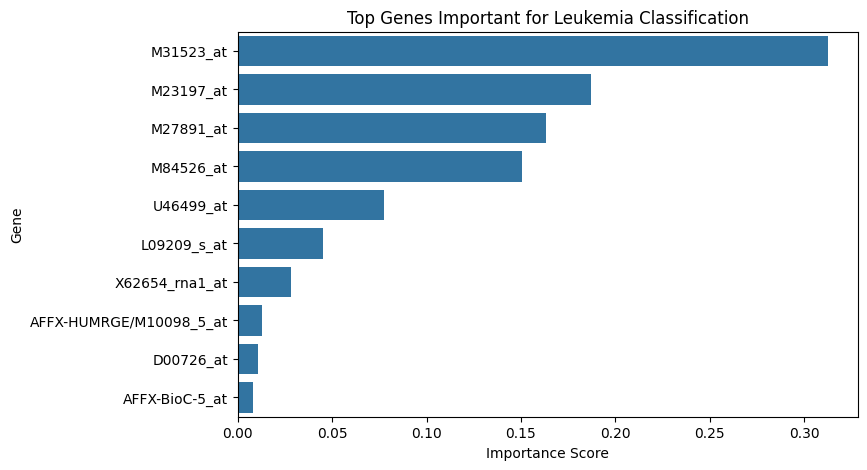

In [19]:
top_genes = feature_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_genes, x="Importance", y="Gene")

plt.title("Top Genes Important for Leukemia Classification")
plt.xlabel("Importance Score")
plt.ylabel("Gene")

plt.show()

In [20]:
import pickle

# save the trained model
with open("../results/leukemia_xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


In [21]:
# save important genes to CSV
feature_importance.to_csv("../results/important_genes.csv", index=False)

print("Gene importance file saved!")

Gene importance file saved!


In [22]:
# combine features and labels
dataset = X.copy()
dataset["label"] = y_encoded

dataset.to_csv("../data/processed/leukemia_processed_data.csv", index=False)

print("Processed dataset saved!")

Processed dataset saved!


In [1]:
from sklearn.decomposition import PCA

In [3]:
# separate features and labels
X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

NameError: name 'df' is not defined

In [2]:
# reduce gene expression data to 2 principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("PCA completed")
print("New shape:", X_pca.shape)

NameError: name 'X' is not defined